<a class="anchor" id="0"></a>
# **Catégorisez automatiquement des questions**


## Contexte :

Stack Overflow est un site célèbre de questions-réponses liées au développement informatique.

Pour poser une question sur ce site, il faut entrer plusieurs tags afin de retrouver facilement la question par la suite. Pour les utilisateurs expérimentés, cela ne pose pas de problème, mais pour les nouveaux utilisateurs, il serait judicieux de suggérer quelques tags relatifs à la question posée.


## Mission :

Amateur de Stack Overflow, qui vous a souvent sauvé la mise, vous décidez d'aider la communauté en retour. Pour cela, vous développez un système de suggestion de tags pour le site. Celui-ci prendra la forme d’un algorithme de machine learning qui assignera automatiquement plusieurs tags pertinents à une question.

## Informations complémentaires :

Stack Overflow propose un outil d’export de données, "StackExchange Data Explorer", qui recense un grand nombre de données authentiques de la plateforme d’entraide. 
Voici la requête SQL utilisée pour obtenir notre fichier csv:

SELECT TOP 50000 Title, Body, Tags, Id
FROM Posts 
WHERE  Score > 50 AND AnswerCount > 5 AND LEN(Tags) - LEN(REPLACE(Tags, '<','')) >= 1
ORDER BY Score


# **Table des matières** <a class="anchor" id="0.1"></a>


- 1 [Chargement de la base de données](#1)
- 2 [Etude de notre jeu de données](#2)
    - 2.1 [Extraction des codes dans les textes](#2.1)
    - 2.2 [Liste des Tags](#2.2)
    - 2.3 [Vectorisation des titres](#2.3)
        - 2.3.1 [Création des fonctions de cleaning et lematiseur de texte](#2.3.1)
        - 2.3.2 [Création des fonctions de préparation de features](#2.3.2)
        - 2.3.3 [Création des features](#2.3.3)
        - 2.3.4 [Transformation des titres par vectorisation](#2.3.4)
    - 2.4 [Visualisation des différents groupes de mots](#2.4)
        - 2.4.1 [Visualisation selon les titres](#2.4.1)
        - 2.4.2 [Visualisation selon les titres et les textes](#2.4.2)
- 3 [Visualisation par gensim](#3)
    - 3.1 [Préparation du corpus](#3.1)
    - 3.2 [Recherche du nombre optimal de topic par étude des valeurs de cohérence](#3.2)
    - 3.3 [Visualisation avec PyLDA pour 8 topics](#3.3)   
- 4 [Préparation du jeu de donnée de test](#4)    





<a class="anchor" id="1"></a>
# **1. Chargement de la base de données** 

[Table des matières](#0.1)



In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.decomposition import NMF,LatentDirichletAllocation
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import MultiLabelBinarizer

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer

import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
from gensim.models.coherencemodel import CoherenceModel

from pprint import pprint
from bs4 import BeautifulSoup 
from sklearn.decomposition import LatentDirichletAllocation
import spacy
import pyLDAvis
import pyLDAvis.gensim
%matplotlib inline

spacy.load('en_core_web_sm')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /home/vortax/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/vortax/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/vortax/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/vortax/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [69]:
df_stackoverflow     = pd.read_csv("QueryResults_stackoverflow.csv")


<a class="anchor" id="2"></a>
# **2. Etude de notre jeu de données** 

[Table des matières](#0.1)



<a class="anchor" id="2.1"></a>
# **2.1 Extraction des paragraphes des textes** 

[Table des matières](#0.1)



In [70]:
df_stackoverflow.Body[1]

"<p>All I want is to update an ListViewItem's text whithout seeing any flickering.</p>\n\n<p>This is my code for updating (called several times):</p>\n\n<pre><code>listView.BeginUpdate();\nlistViewItem.SubItems[0].Text = state.ToString();    // update the state\nlistViewItem.SubItems[1].Text = progress.ToString(); // update the progress\nlistView.EndUpdate();\n</code></pre>\n\n<p>I've seen some solutions that involve overriding the component's <code>WndProc():</code></p>\n\n<pre><code>protected override void WndProc(ref Message m)\n{\n    if (m.Msg == (int)WM.WM_ERASEBKGND)\n    {\n        m.Msg = (int)IntPtr.Zero;\n    }\n    base.WndProc(ref m);\n}\n</code></pre>\n\n<p><strong>They say it solves the problem, but in my case It didn't</strong>. I believe this is because I'm using icons on every item.</p>\n"

In [71]:
BeautifulSoup(df_stackoverflow.Body[1]).find_all(string=True)
blocklist = [
  'code','pre','a'
]

text_elements = [t for t in BeautifulSoup(df_stackoverflow.Body[1]).find_all(
    string=True) if t.parent.name not in blocklist and t!='\n']
text_elements

["All I want is to update an ListViewItem's text whithout seeing any flickering.",
 'This is my code for updating (called several times):',
 "I've seen some solutions that involve overriding the component's ",
 "They say it solves the problem, but in my case It didn't",
 ". I believe this is because I'm using icons on every item."]

In [72]:
text = str()
for i in range(len(text_elements)):
    text=text+text_elements[i]
text

"All I want is to update an ListViewItem's text whithout seeing any flickering.This is my code for updating (called several times):I've seen some solutions that involve overriding the component's They say it solves the problem, but in my case It didn't. I believe this is because I'm using icons on every item."

In [73]:
def text_extract(row) : 
    blocklist = [  'code','pre','a']
    text_elements = [t for t in BeautifulSoup(row).find_all(
    string=True) if t.parent.name not in blocklist and t!='\n']
    text = str()
    for i in range(len(text_elements)) : 
        text = text+text_elements[i]
    return text

<a class="anchor" id="2.2"></a>
# **2.2 Liste des Tags** 

[Table des matières](#0.1)



In [74]:
def Tags_to_list (row) :
    Tags_list =[] 
    for j in range(5):
            if row['Tag_'+str(j)] is not np.nan : 
                Tags_list.append(row['Tag_'+str(j)])
    return Tags_list

def Tags_extract(df) : 
    dict_tags = dict()
    df['Len_tags'] = int()
    for i,row in enumerate(df.Tags) : 
        tags  = row.replace('<','').split('>')[0:-1]
        df.loc[i,'Len_tags'] = len(tags)
        for j,element in enumerate(tags) :
            df.loc[i,'Tag_'+str(j)]= element
            if element in dict_tags.keys():
                dict_tags[element]['List_id'].append(df.Id[i])
                dict_tags[element]['List_tags'].append(len(tags)-1)
            else :
                dict_tags[element]=dict()
                dict_tags[element]['List_id'] = [df.Id[i]]
                dict_tags[element]['List_tags'] = [len(tags)-1]
    df_tags = pd.DataFrame(index=dict_tags.keys(),columns=['Number_tags','Mean_tags'])
    for tags in df_tags.index : 
        df_tags.loc[tags,['Number_tags']] = len(dict_tags[tags]['List_id'])
    df_tags = df_tags.sort_values(['Number_tags'],ascending=False)
    list_best_tags = df_tags[0:30].index
    df_best_tags = df_tags.loc[list_best_tags]
    df_30_tags = pd.concat(df[df['Id'].isin(
                    dict_tags[tags]['List_id'])] for tags in list_best_tags).drop_duplicates().drop(
        'Tags',axis=1).reset_index(drop=True)
    cleaning_df = df_30_tags[['Tag_0','Tag_1','Tag_2','Tag_3','Tag_4']].isin(list_best_tags)
    for j in range(5):
        df_30_tags['Tag_'+str(j)][cleaning_df['Tag_'+str(j)]!= True] = np.nan
    df_30_tags['New_len_tags'] = cleaning_df.sum(axis=1) 
    df_30_tags['Tags'] =  df_30_tags.apply(lambda x : Tags_to_list(x),axis=1)
    df_30_tags.drop(['Tag_0','Tag_1','Tag_2','Tag_3','Tag_4'],axis=1,inplace=True)
    return df_best_tags,df_30_tags


In [75]:
df_best_tags,df_study = Tags_extract(df_stackoverflow)
df_study.head()

/tmp/ipykernel_87916/1729458963.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_30_tags['Tag_'+str(j)][cleaning_df['Tag_'+str(j)]!= True] = np.nan


,Title,Body,Id,Len_tags,New_len_tags,Tags
0,how to clear or replace a cached image,<p>I know there are many ways to prevent image...,321865,4,1,[javascript]
1,Getting mouse location in canvas,<p>Is there a way to get the location mouse in...,1114465,3,2,"[javascript, html]"
2,Image resize before upload,<p>I need to provide a means for a user to upl...,961913,2,1,[javascript]
3,Send array via GET request with AngularJS' $ht...,<p>I need to send a GET request using the <cod...,19957858,4,1,[javascript]
4,Scale a div to fit in window but preserve aspe...,<p>How can I scale a div to fit inside the bro...,1311068,4,4,"[javascript, jquery, css, html]"


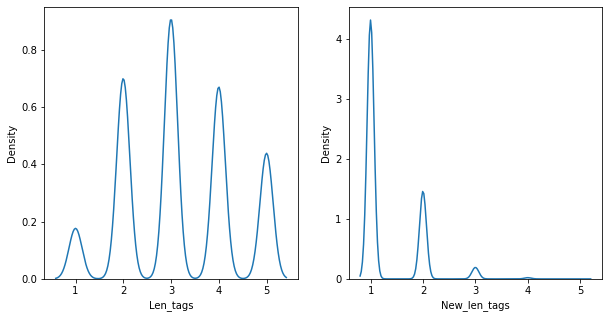

In [76]:
figure,axes = plt.subplots(1,2,figsize=(10,5))
sns.kdeplot(df_study['Len_tags'],ax=axes[0])
sns.kdeplot(df_study['New_len_tags'],ax=axes[1])
plt.show()

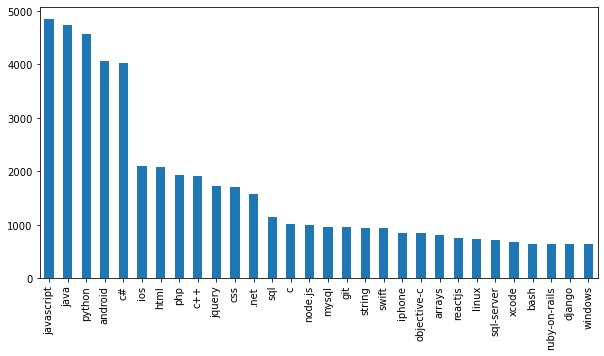

In [77]:
figure = plt.subplots(figsize=(10,5))
df_best_tags['Number_tags'].plot.bar()
plt.show()

<a class="anchor" id="2.3"></a>
# **2.3 Vectorisation des titres** 

[Table des matières](#0.1)



<a class="anchor" id="2.3.1"></a>
# **2.3.1 Création des fonctions de cleaning et lematiseur de texte** 

[Table des matières](#0.1)



In [78]:
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

from nltk.corpus import stopwords
stop_w = list(set(stopwords.words('english'))) + ['[', ']', ',', '.', ':', '?', '(', ')']

def text_extract(row) : 
    blocklist = [  'code','pre','a']
    text_elements = [t for t in BeautifulSoup(row).find_all(
    string=True) if t.parent.name not in blocklist and t!='\n']
    text = str()
    for i in range(len(text_elements)) : 
        text = text+text_elements[i]
    return text

def sent_to_words(sentences):
    yield(gensim.utils.simple_preprocess(str(sentences), deacc=True))
    return sent_to_words(sentences)

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_w] for doc in texts]

def lemmatization_spacy(texts, allowed_postags=['NOUN','PROPN']):
    texts_out = []
    for sent in texts :
        doc = nlp(" ".join(sent)) 
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return texts_out


In [79]:
doc = nlp(text_extract(df_study['Body'][536]))
for token in doc:
    # Get the token text, part-of-speech tag and dependency label
    token_text = token.text
    token_pos = token.pos_
    token_dep = token.dep_
    # This is for formatting only
    print('{:<12}{:<10}{:<10}'.format(token_text, token_pos, token_dep))

How         SCONJ               
to          PART                
simply      ADV                 
flatten     VERB                
array       NOUN                
in          ADP                 
jQuery      PROPN               
?           PUNCT               
I           PRON                
have        AUX                 
:           PUNCT               
And         CCONJ               
I           PRON                
want        VERB                
:           PUNCT               


<a class="anchor" id="2.3.2"></a>
# **2.3.2 Création des fonctions de préparation de features** 

[Table des matières](#0.1)

In [80]:
def transform_bow_lem_spacy_fct(desc_text) :
    word_tokens = list(sent_to_words(desc_text))
    sw = remove_stopwords(word_tokens)
    lem_w = lemmatization_spacy(sw)  
    transf_desc_text = ' '.join(lem_w[0])
    return transf_desc_text

def transform_text_bow_lem_spacy_fct(desc_text) :
    text = text_extract(desc_text)
    word_tokens = list(sent_to_words(text))
    
    lem_w = lemmatization_spacy(word_tokens) 
    sw = remove_stopwords(lem_w)
    transf_desc_text = ' '.join(lem_w[0])
    return transf_desc_text


In [81]:
transform_text_bow_lem_spacy_fct(df_study['Body'][536])

'array jquery'

<a class="anchor" id="2.3.3"></a>
# **2.3.3 Création des features** 

[Table des matières](#0.1)

In [82]:
df_study['Title_bow_lem'] = df_study['Title'].apply(transform_bow_lem_spacy_fct)
df_study['Text_bow_lem'] = df_study['Body'].apply(transform_text_bow_lem_spacy_fct)
df_study.head()

,Title,Body,Id,Len_tags,New_len_tags,Tags,Title_bow_lem,Text_bow_lem
0,how to clear or replace a cached image,<p>I know there are many ways to prevent image...,321865,4,1,[javascript],image,way image tag trick version image page load im...
1,Getting mouse location in canvas,<p>Is there a way to get the location mouse in...,1114465,3,2,"[javascript, html]",mouse location canvas,way location mouse tag location corner page
2,Image resize before upload,<p>I need to provide a means for a user to upl...,961913,2,1,[javascript],image resize upload,mean user photo web site jpeg format photo siz...
3,Send array via GET request with AngularJS' $ht...,<p>I need to send a GET request using the <cod...,19957858,4,1,[javascript],array request angularjs http service,request service parameter array ids url mysite...
4,Scale a div to fit in window but preserve aspe...,<p>How can I scale a div to fit inside the bro...,1311068,4,4,"[javascript, jquery, css, html]",scale div window aspect ratio,div browser view port aspect ratio div css jqu...


In [83]:
df_study['Length_bow_title'] = df_study['Title_bow_lem'].apply(lambda x : len(word_tokenize(x)))
print("max length bow Title : ", df_study['Length_bow_title'].max())
df_study['Length_bow_text'] = df_study['Text_bow_lem'].apply(lambda x : len(word_tokenize(x)))
print("max length bow Text : ", df_study['Length_bow_text'].max())
df_study['Text_Title'] = df_study['Title_bow_lem']+' '+df_study['Text_bow_lem']
df_study.head()

max length bow Title :  15
max length bow Text :  761


,Title,Body,Id,Len_tags,New_len_tags,Tags,Title_bow_lem,Text_bow_lem,Length_bow_title,Length_bow_text,Text_Title
0,how to clear or replace a cached image,<p>I know there are many ways to prevent image...,321865,4,1,[javascript],image,way image tag trick version image page load im...,1,48,image way image tag trick version image page l...
1,Getting mouse location in canvas,<p>Is there a way to get the location mouse in...,1114465,3,2,"[javascript, html]",mouse location canvas,way location mouse tag location corner page,3,7,mouse location canvas way location mouse tag l...
2,Image resize before upload,<p>I need to provide a means for a user to upl...,961913,2,1,[javascript],image resize upload,mean user photo web site jpeg format photo siz...,3,40,image resize upload mean user photo web site j...
3,Send array via GET request with AngularJS' $ht...,<p>I need to send a GET request using the <cod...,19957858,4,1,[javascript],array request angularjs http service,request service parameter array ids url mysite...,5,35,array request angularjs http service request s...
4,Scale a div to fit in window but preserve aspe...,<p>How can I scale a div to fit inside the bro...,1311068,4,4,"[javascript, jquery, css, html]",scale div window aspect ratio,div browser view port aspect ratio div css jqu...,5,10,scale div window aspect ratio div browser view...


In [84]:
df_study.head()

,Title,Body,Id,Len_tags,New_len_tags,Tags,Title_bow_lem,Text_bow_lem,Length_bow_title,Length_bow_text,Text_Title
0,how to clear or replace a cached image,<p>I know there are many ways to prevent image...,321865,4,1,[javascript],image,way image tag trick version image page load im...,1,48,image way image tag trick version image page l...
1,Getting mouse location in canvas,<p>Is there a way to get the location mouse in...,1114465,3,2,"[javascript, html]",mouse location canvas,way location mouse tag location corner page,3,7,mouse location canvas way location mouse tag l...
2,Image resize before upload,<p>I need to provide a means for a user to upl...,961913,2,1,[javascript],image resize upload,mean user photo web site jpeg format photo siz...,3,40,image resize upload mean user photo web site j...
3,Send array via GET request with AngularJS' $ht...,<p>I need to send a GET request using the <cod...,19957858,4,1,[javascript],array request angularjs http service,request service parameter array ids url mysite...,5,35,array request angularjs http service request s...
4,Scale a div to fit in window but preserve aspe...,<p>How can I scale a div to fit inside the bro...,1311068,4,4,"[javascript, jquery, css, html]",scale div window aspect ratio,div browser view port aspect ratio div css jqu...,5,10,scale div window aspect ratio div browser view...


<AxesSubplot:xlabel='Length_bow_text', ylabel='Density'>

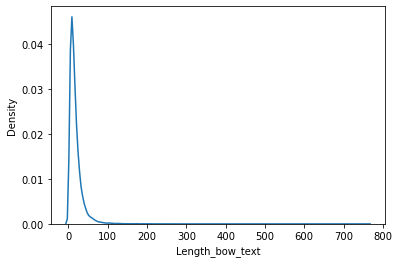

In [85]:
sns.kdeplot(df_study['Length_bow_text'])

<a class="anchor" id="2.3.4"></a>
# **2.3.4 Transformation des titres par vectorisation** 

[Table des matières](#0.1)

https://www.machinelearningplus.com/nlp/topic-modeling-gensim-python/#17howtofindtheoptimalnumberoftopicsforlda

https://towardsdatascience.com/evaluate-topic-model-in-python-latent-dirichlet-allocation-lda-7d57484bb5d0

https://towardsdatascience.com/sentiment-analysis-using-lstm-and-glove-embeddings-99223a87fe8e

https://www.analyticsvidhya.com/blog/2021/12/multiclass-classification-using-transformers/

https://medium.com/mlreview/topic-modeling-with-scikit-learn-e80d33668730

PyldaVis => visualisation des topics et de la cohérence
Spacy => lemmatizer seulement nom
BeautifulSoup => gestion du html

In [86]:
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(2, 5, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx +1}", fontdict={"fontsize": 30})
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

<a class="anchor" id="2.4"></a>
# **2.4 Visualisation des différents groupes de mots** 

[Table des matières](#0.1)

In [87]:
df_study=df_study[df_study['Text_Title']!=' '].reset_index(drop=True)
df_study.to_csv('tags_full')

<a class="anchor" id="2.4.1"></a>
# **2.4.1 Visualisation selon les titres** 

[Table des matières](#0.1)

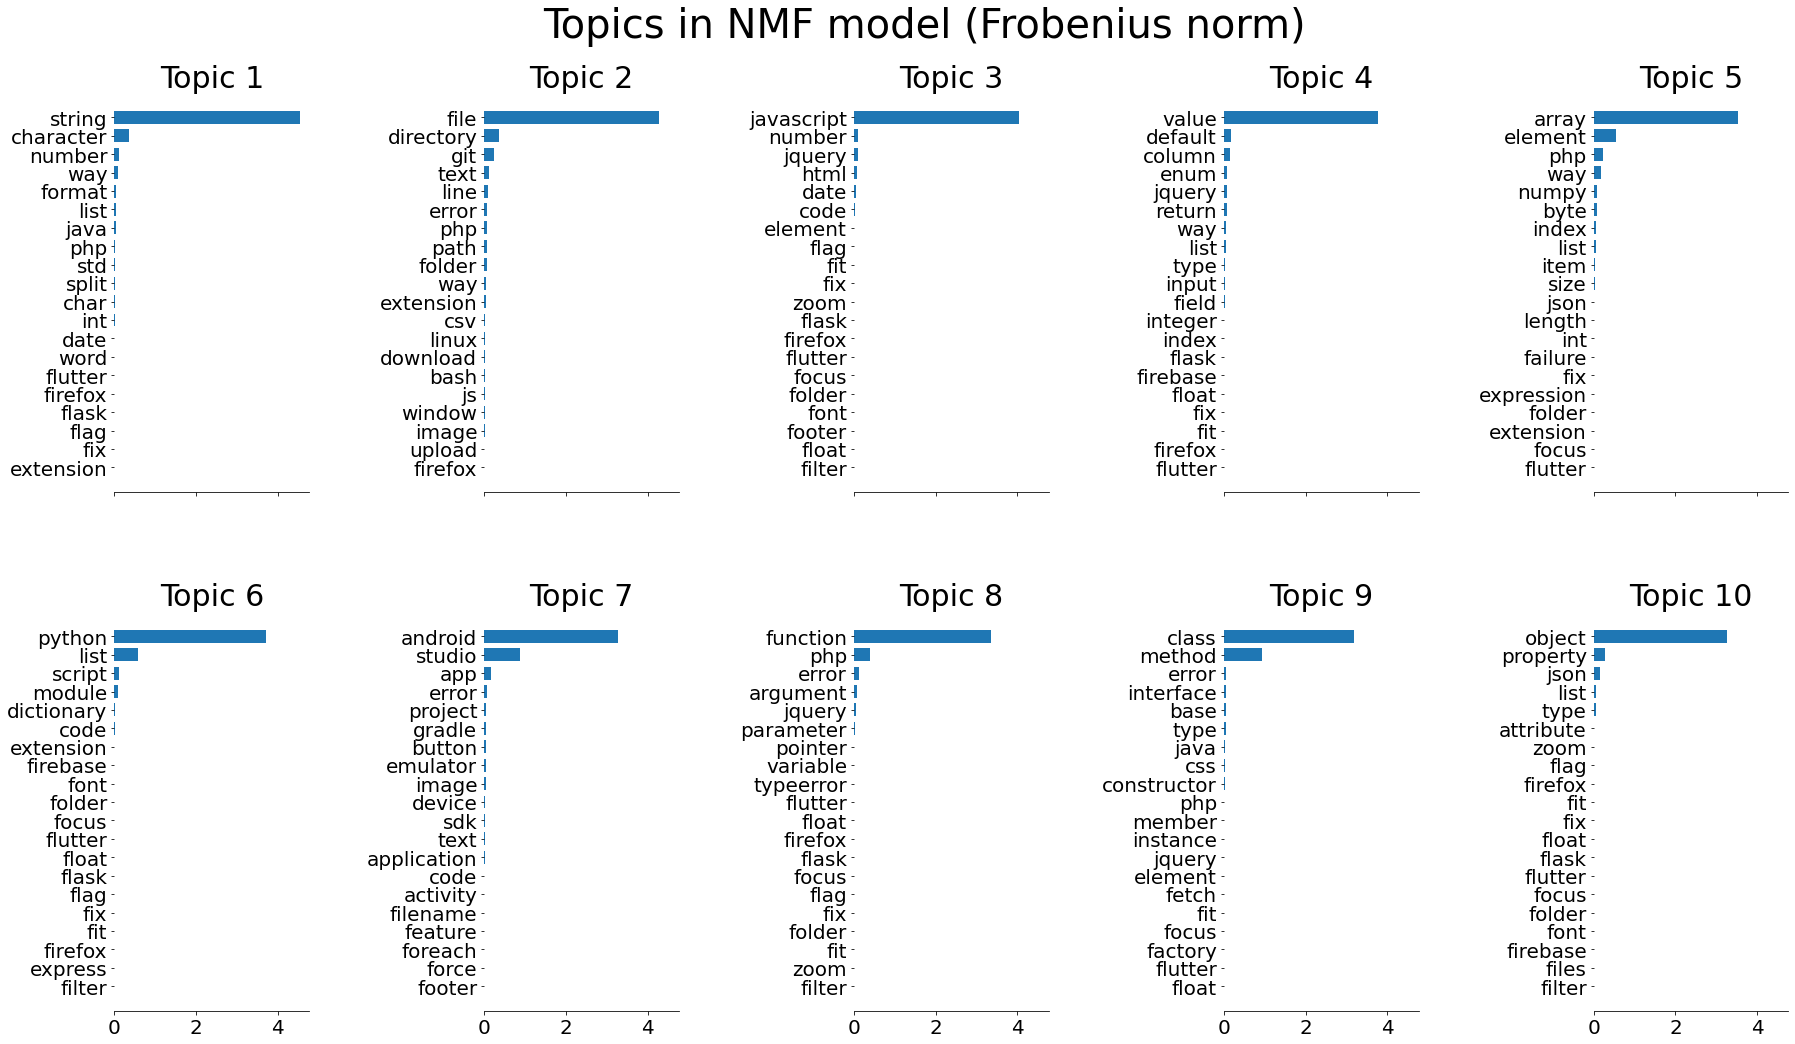

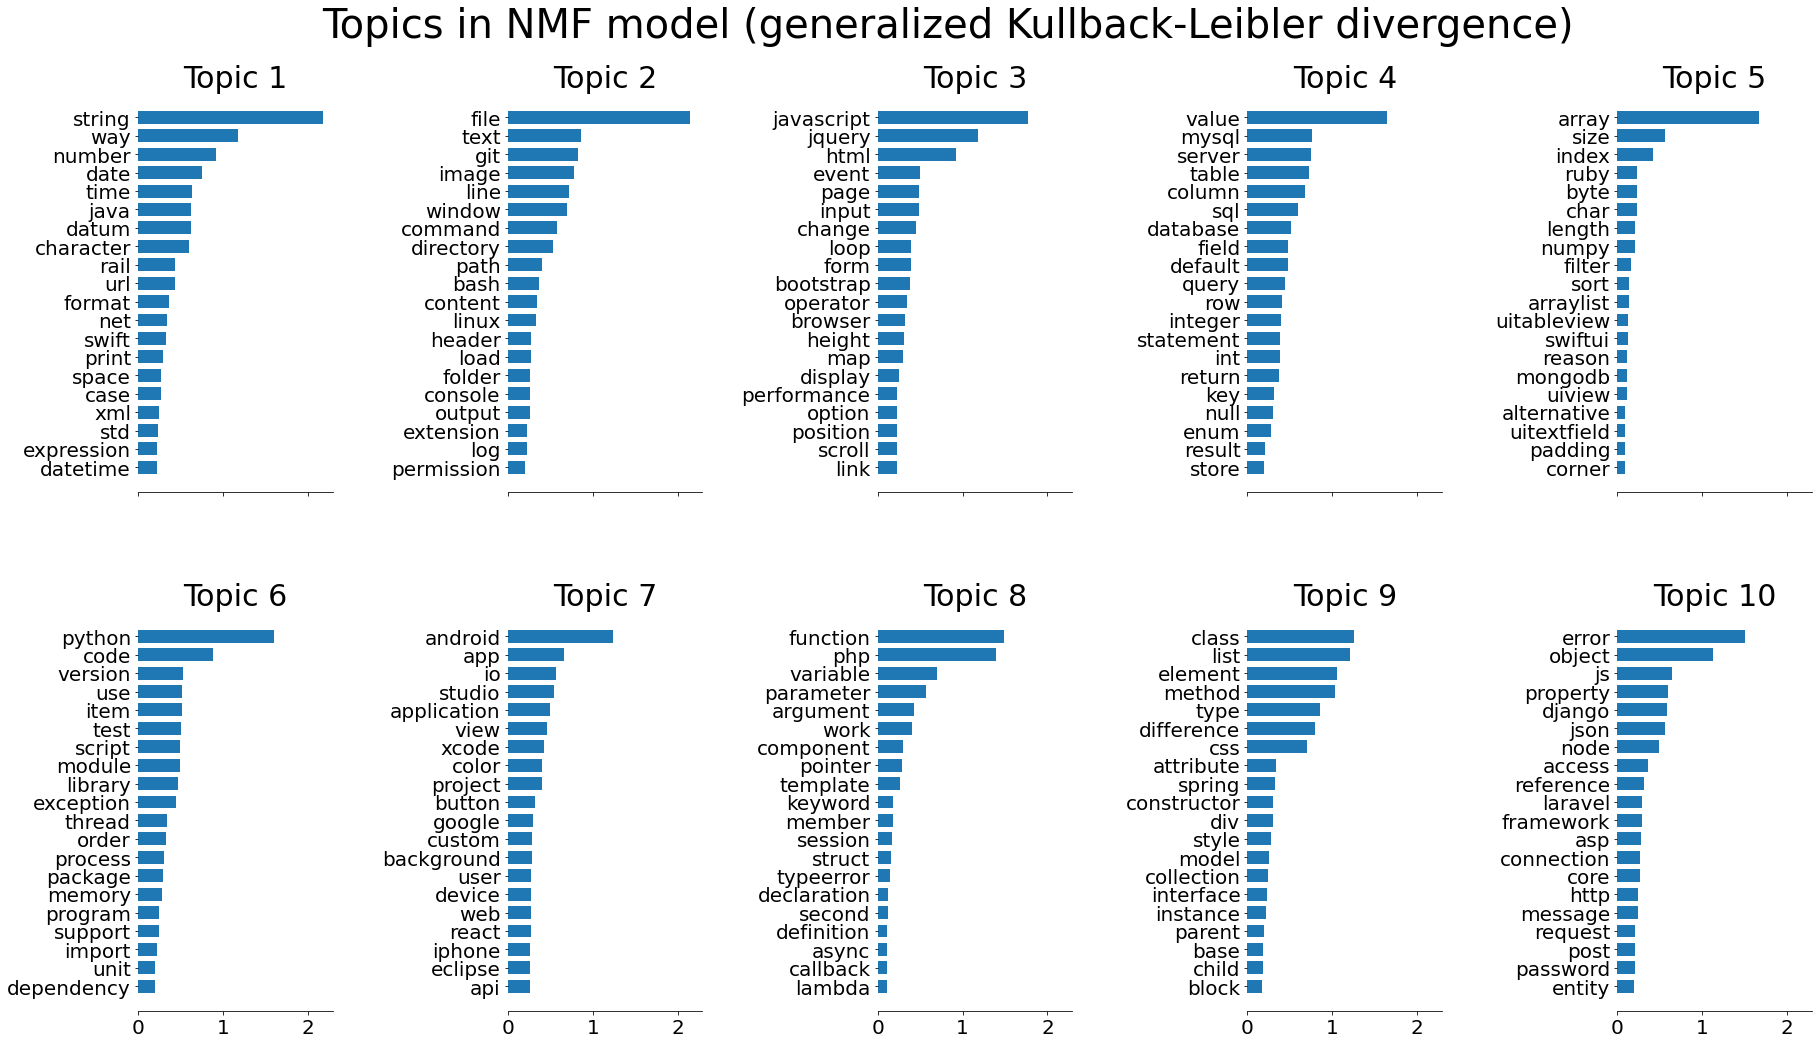

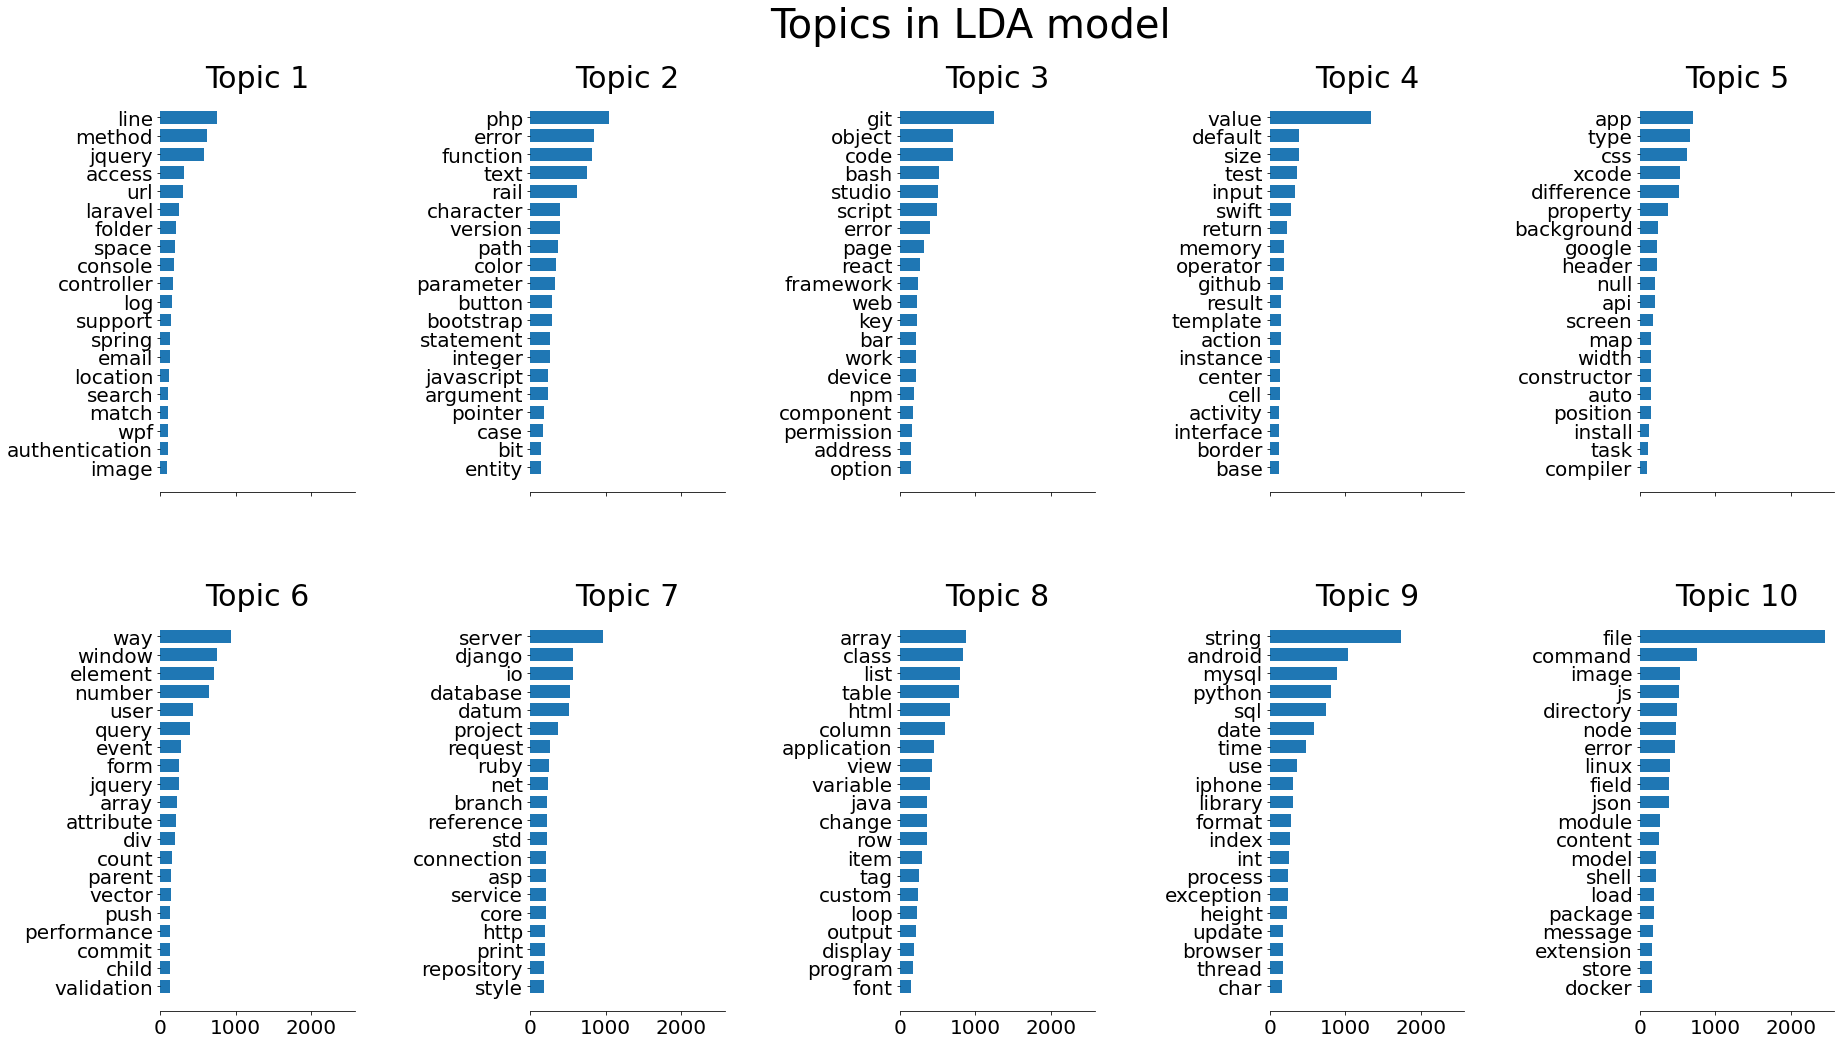

In [88]:
n_samples = 2000
n_features = 1000
n_components = 10
n_top_words = 20
batch_size = 128
init = "nndsvda"

tfidf_vectorizer = TfidfVectorizer(max_df=0.5, min_df=5, stop_words="english",
    max_features = n_features)

tfidf = tfidf_vectorizer.fit_transform(df_study['Title_bow_lem'])

tf_vectorizer = CountVectorizer(max_df=0.5, min_df=5, stop_words="english",
    max_features = n_features)

tf = tf_vectorizer.fit_transform(df_study['Title_bow_lem'])

nmf = NMF(n_components=n_components, random_state=1, init=init,
    beta_loss="frobenius", alpha_W=0.00005, alpha_H=0.00005, l1_ratio=1).fit(tfidf)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(nmf, tfidf_feature_names, n_top_words, "Topics in NMF model (Frobenius norm)")

nmf = NMF(n_components=n_components, random_state=1, init=init, beta_loss="kullback-leibler",
    solver="mu", max_iter=1000, alpha_W=0.00005, alpha_H=0.00005, l1_ratio=0.5).fit(tfidf)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(nmf, tfidf_feature_names, n_top_words,
    "Topics in NMF model (generalized Kullback-Leibler divergence)")


lda = LatentDirichletAllocation(
    n_components=n_components,
    max_iter=5,
    learning_method="online",
    learning_offset=50.0,
    random_state=0,
)

lda.fit(tf)

tf_feature_names = tf_vectorizer.get_feature_names_out()
plot_top_words(lda, tf_feature_names, n_top_words, "Topics in LDA model")

<a class="anchor" id="2.4.2"></a>
# **2.4.2 Visualisation selon les titres et les textes** 

[Table des matières](#0.1)

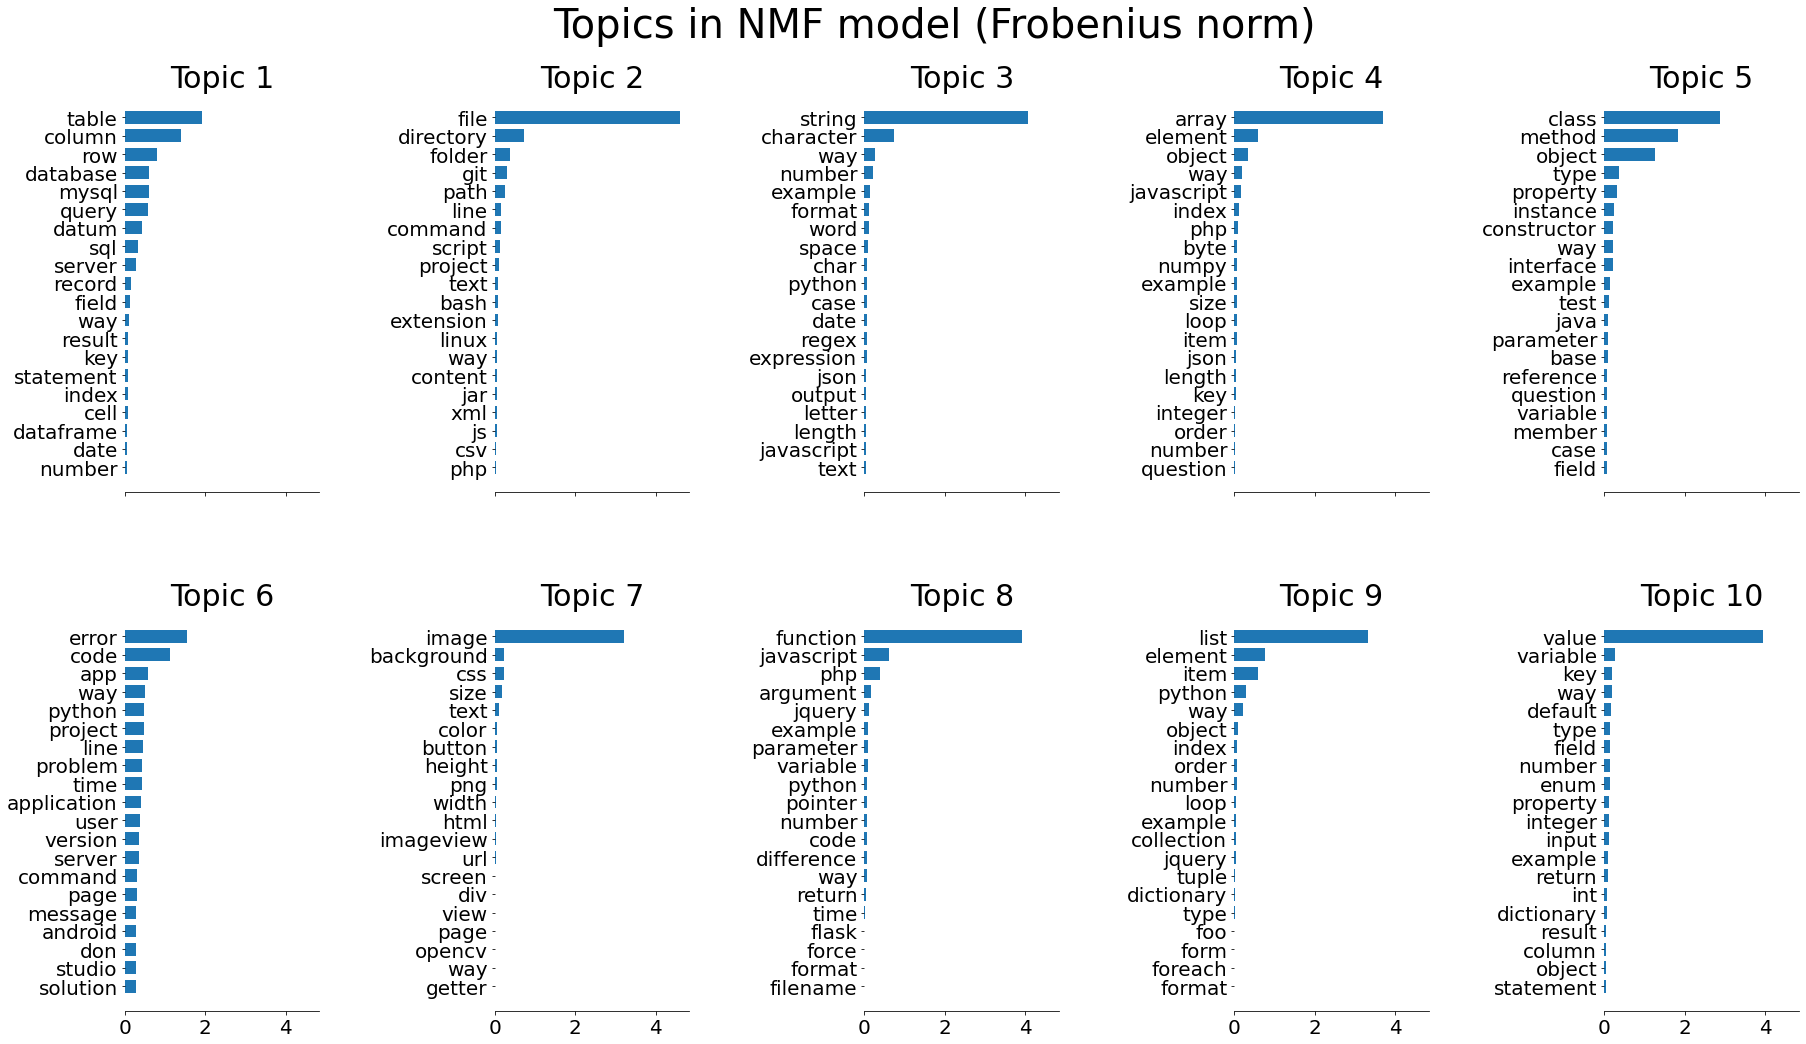

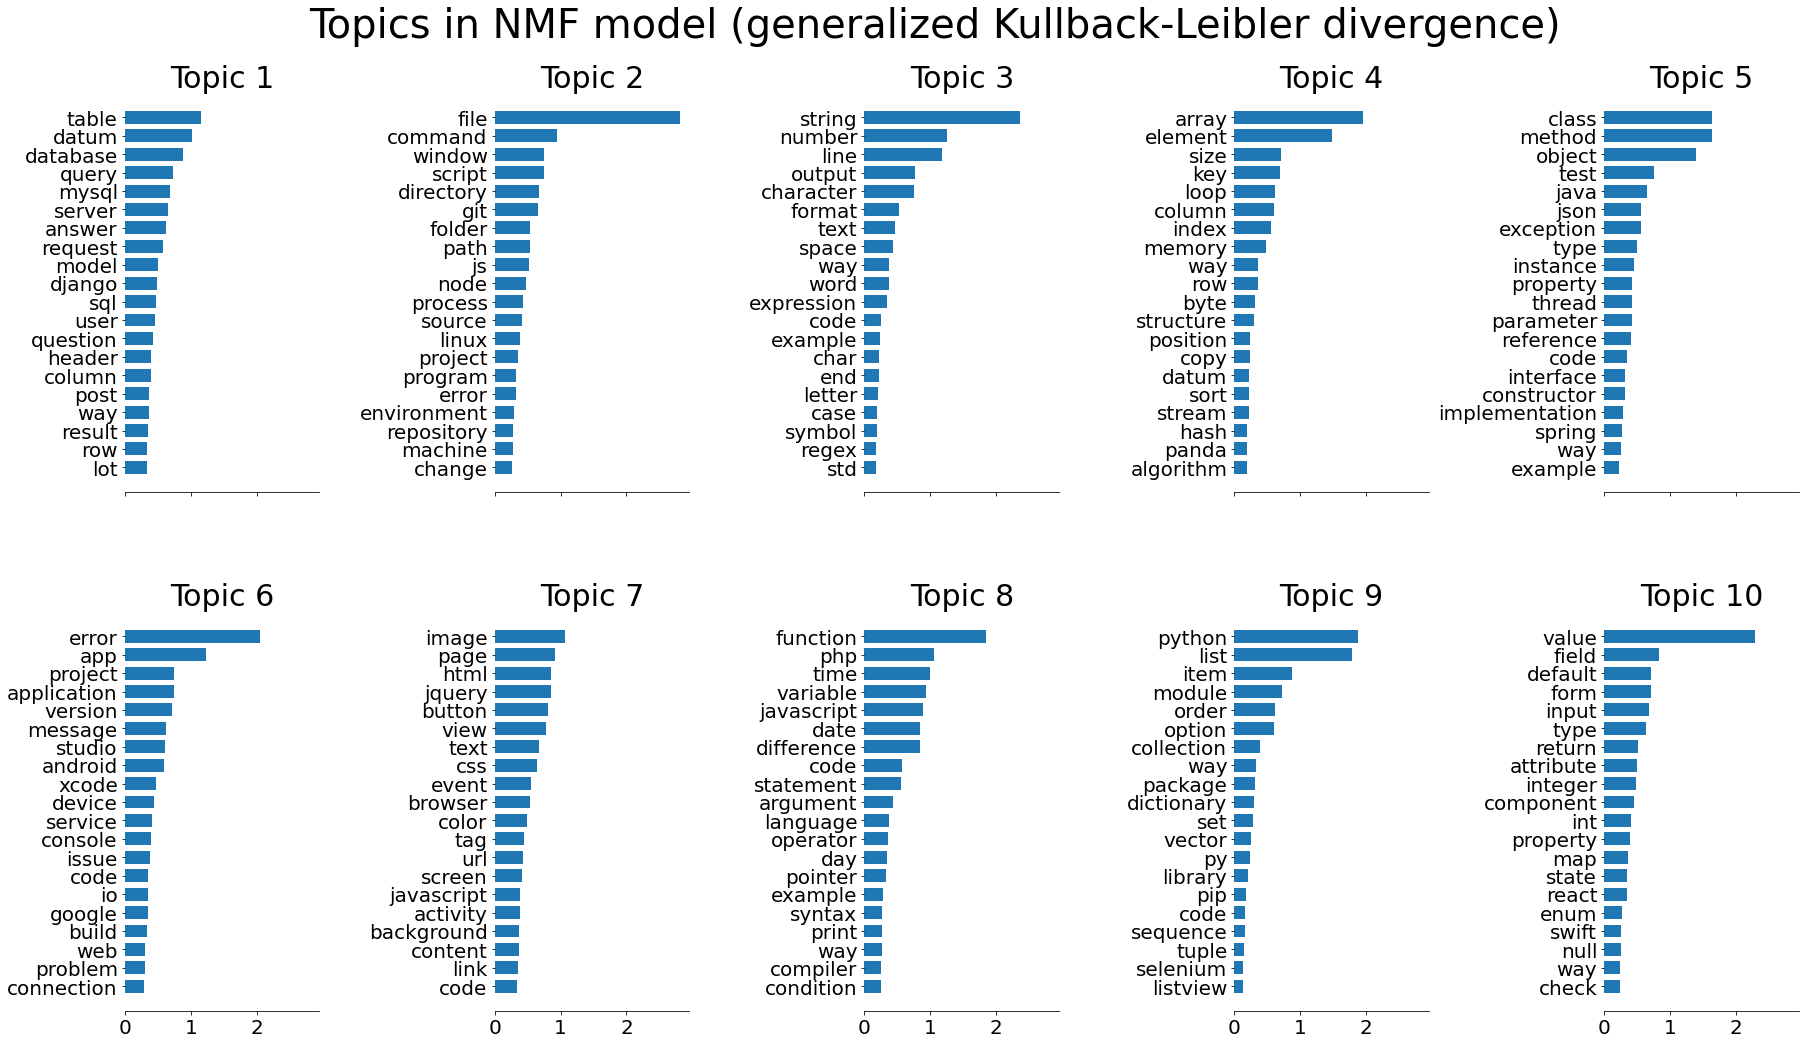

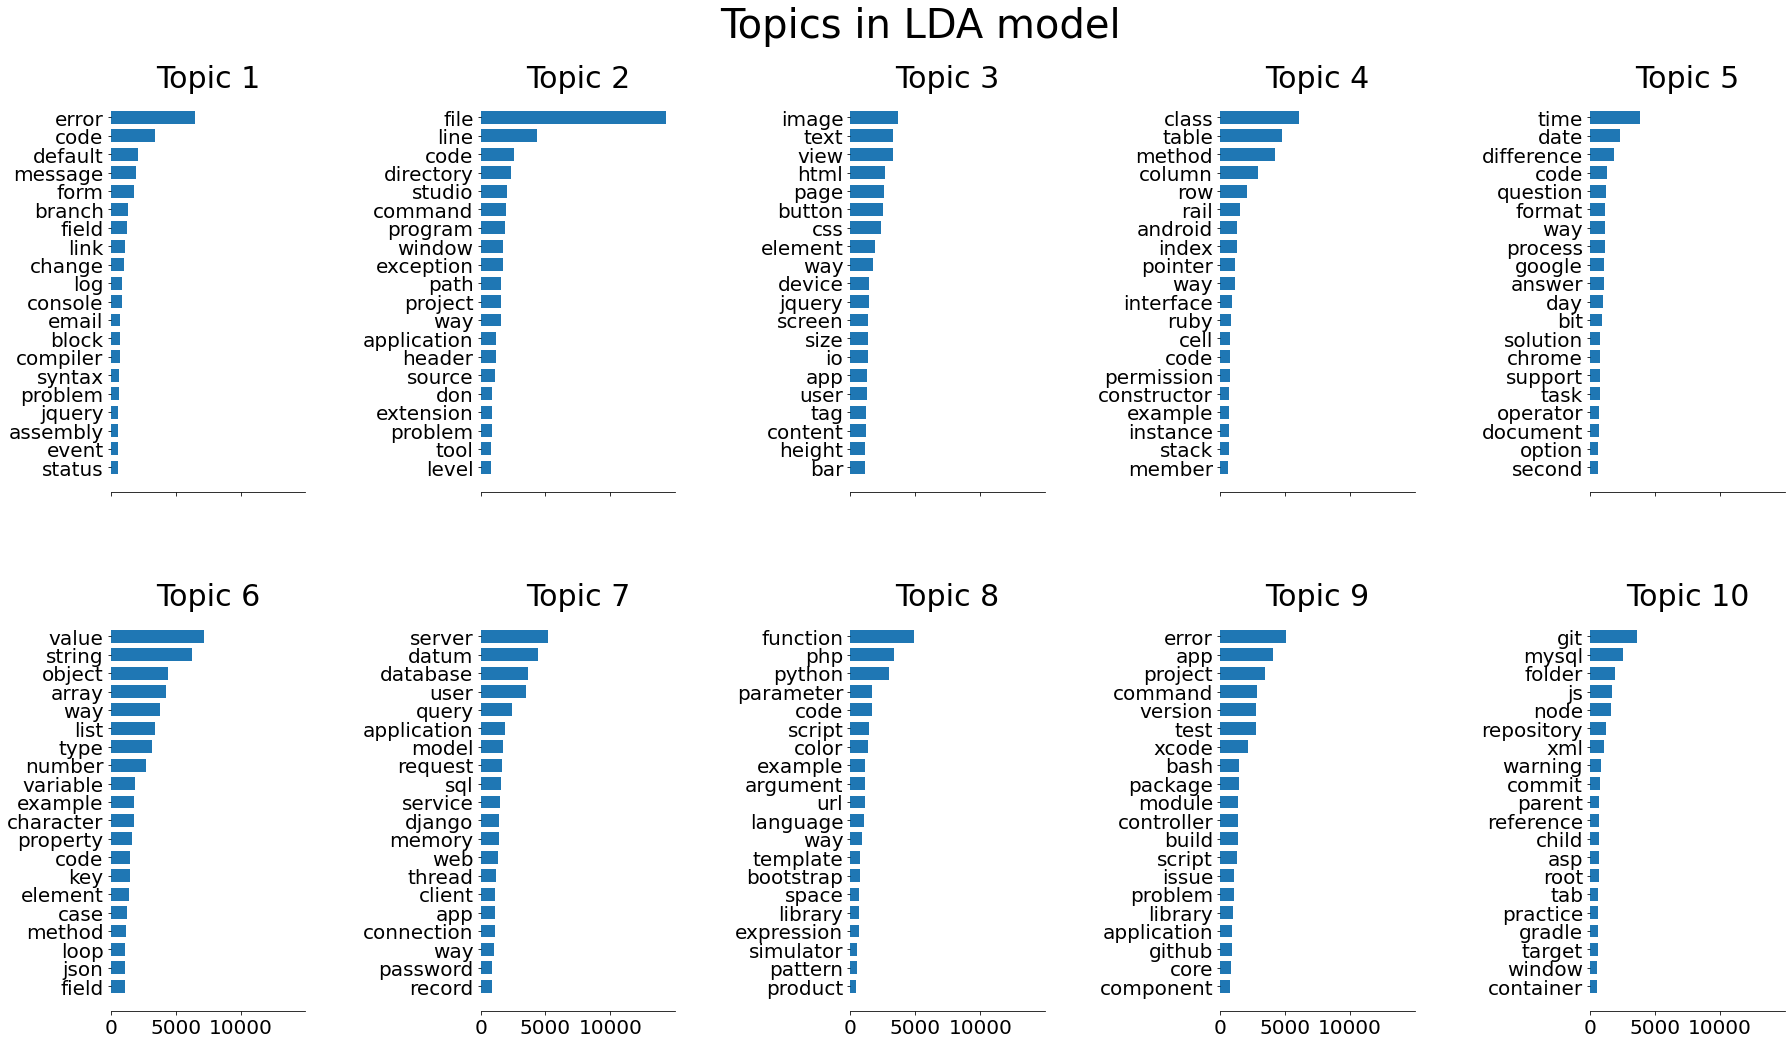

In [89]:
n_samples = 2000
n_features = 1000
n_components = 10
n_top_words = 20
batch_size = 128
init = "nndsvda"

tfidf_vectorizer = TfidfVectorizer(max_df=0.5, min_df=5, stop_words="english",
    max_features = n_features)

tfidf = tfidf_vectorizer.fit_transform(df_study['Text_Title'])

tf_vectorizer = CountVectorizer(max_df=0.5, min_df=5, stop_words="english",
    max_features = n_features)

tf = tf_vectorizer.fit_transform(df_study['Text_Title'])

nmf = NMF(n_components=n_components, random_state=1, init=init,
    beta_loss="frobenius", alpha_W=0.00005, alpha_H=0.00005, l1_ratio=1).fit(tfidf)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(nmf, tfidf_feature_names, n_top_words, "Topics in NMF model (Frobenius norm)")

nmf = NMF(n_components=n_components, random_state=1, init=init, beta_loss="kullback-leibler",
    solver="mu", max_iter=1000, alpha_W=0.00005, alpha_H=0.00005, l1_ratio=0.5).fit(tfidf)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(nmf, tfidf_feature_names, n_top_words,
    "Topics in NMF model (generalized Kullback-Leibler divergence)")


lda = LatentDirichletAllocation(
    n_components=n_components,
    max_iter=5,
    learning_method="online",
    learning_offset=50.0,
    random_state=0,
)

lda.fit(tf)

tf_feature_names = tf_vectorizer.get_feature_names_out()
plot_top_words(lda, tf_feature_names, n_top_words, "Topics in LDA model")

<a class="anchor" id="3"></a>
# **3. Visualisation par gensim** 

[Table des matières](#0.1)

<a class="anchor" id="3.1"></a>
# **3.1 Préparation du corpus** 

[Table des matières](#0.1)

In [90]:
texts = list(sent_to_words(df_study['Text_Title']))
test = list( df_study['Text_Title'][i].split(' ') for i in range(len(df_study['Text_Title'])))
             
id2word = corpora.Dictionary(test)

corpus = [id2word.doc2bow(text) for text in test]


In [91]:
corpus[0:5]

[[(0, 1),
  (1, 1),
  (2, 2),
  (3, 1),
  (4, 1),
  (5, 10),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 6),
  (10, 1),
  (11, 3),
  (12, 1),
  (13, 3),
  (14, 4),
  (15, 1),
  (16, 2),
  (17, 1),
  (18, 2),
  (19, 1),
  (20, 1),
  (21, 4)],
 [(14, 1), (16, 1), (21, 1), (22, 1), (23, 1), (24, 3), (25, 2)],
 [(3, 1),
  (5, 3),
  (8, 2),
  (15, 1),
  (26, 1),
  (27, 2),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 3),
  (36, 3),
  (37, 1),
  (38, 3),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 2),
  (43, 2),
  (44, 1),
  (45, 1),
  (46, 3),
  (47, 2),
  (48, 2)],
 [(15, 1),
  (21, 1),
  (41, 2),
  (49, 1),
  (50, 2),
  (51, 1),
  (52, 2),
  (53, 5),
  (54, 1),
  (55, 1),
  (56, 4),
  (57, 1),
  (58, 1),
  (59, 2),
  (60, 1),
  (61, 1),
  (62, 1),
  (63, 2),
  (64, 1),
  (65, 1),
  (66, 2),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 2),
  (71, 1)],
 [(1, 1),
  (61, 1),
  (68, 1),
  (72, 2),
  (73, 1),
  (74, 3),
  (75, 1),
  (76, 2),
  (77, 1),
  (78, 1),
  (79, 1)

In [92]:
[[(id2word[id], freq) for id, freq in cp] for cp in corpus]

[[('brain', 1),
  ('browser', 1),
  ('cache', 2),
  ('don', 1),
  ('example', 1),
  ('image', 10),
  ('internet', 1),
  ('isn', 1),
  ('javascript', 1),
  ('jpg', 6),
  ('let', 1),
  ('load', 3),
  ('luck', 1),
  ('method', 3),
  ('page', 4),
  ('suggestion', 1),
  ('tag', 2),
  ('time', 1),
  ('timestamp', 2),
  ('trick', 1),
  ('version', 1),
  ('way', 4)],
 [('page', 1),
  ('tag', 1),
  ('way', 1),
  ('canvas', 1),
  ('corner', 1),
  ('location', 3),
  ('mouse', 2)],
 [('don', 1),
  ('image', 3),
  ('javascript', 2),
  ('suggestion', 1),
  ('application', 1),
  ('client', 2),
  ('effortless', 1),
  ('format', 1),
  ('hook', 1),
  ('jpeg', 1),
  ('library', 1),
  ('mean', 1),
  ('operation', 1),
  ('option', 3),
  ('photo', 3),
  ('pointer', 1),
  ('resize', 3),
  ('resizing', 1),
  ('scenario', 1),
  ('service', 1),
  ('side', 2),
  ('site', 2),
  ('size', 1),
  ('tool', 1),
  ('upload', 3),
  ('user', 2),
  ('web', 2)],
 [('suggestion', 1),
  ('way', 1),
  ('service', 2),
  ('angul

<a class="anchor" id="3.2"></a>
# **3.2 Recherche du nombre optimal de topic par étude des valeurs de cohérence** 

[Table des matières](#0.1)

In [93]:
def compute_coherence_values(dictionary, corpus,  limit, start=2, step=3):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=num_topics, 
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)
        coherencemodel = CoherenceModel(
            model=model, corpus=corpus, dictionary=dictionary, coherence='u_mass')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

In [94]:
model_list, coherence_values = compute_coherence_values(dictionary=id2word, corpus=corpus, start=2, limit=20, step=3)

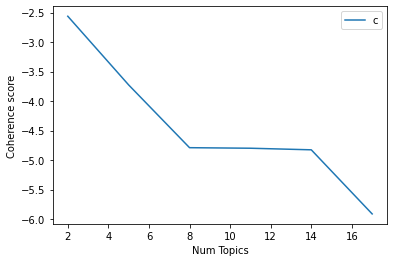

In [95]:
limit=20; start=2; step=3;
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

<a class="anchor" id="3.3"></a>
# **3.3 Visualisation avec PyLDA pour 8 topics** 

[Table des matières](#0.1)

In [96]:
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=8, 
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)

In [97]:
test = CoherenceModel(model=lda_model, corpus=corpus,dictionary=id2word,
  coherence='u_mass')
test.get_coherence_per_topic() 

[-3.0025535542870565,
 -6.413721877727615,
 -5.3862864424060435,
 -3.503082072232483,
 -8.954184826015073,
 -2.4612203903045136,
 -5.1615845541548815,
 -3.445909481294985]

In [98]:
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.059*"value" + 0.048*"string" + 0.039*"field" + 0.036*"array" + '
  '0.035*"function" + 0.034*"variable" + 0.034*"object" + 0.030*"number" + '
  '0.027*"time" + 0.026*"type"'),
 (1,
  '0.126*"app" + 0.059*"process" + 0.051*"default" + 0.045*"docker" + '
  '0.029*"connection" + 0.028*"repository" + 0.024*"prompt" + 0.019*"iphone" + '
  '0.019*"install" + 0.016*"device"'),
 (2,
  '0.103*"test" + 0.053*"request" + 0.026*"http" + 0.024*"google" + '
  '0.023*"authentication" + 0.023*"header" + 0.023*"account" + 0.022*"network" '
  '+ 0.022*"resource" + 0.022*"rspec"'),
 (3,
  '0.072*"server" + 0.046*"database" + 0.038*"table" + 0.031*"datum" + '
  '0.027*"output" + 0.025*"system" + 0.024*"machine" + 0.024*"column" + '
  '0.023*"view" + 0.021*"query"'),
 (4,
  '0.245*"django" + 0.072*"environment" + 0.068*"gem" + 0.035*"button" + '
  '0.027*"group" + 0.026*"css" + 0.024*"none" + 0.022*"heroku" + 0.014*"style" '
  '+ 0.014*"zip"'),
 (5,
  '0.066*"command" + 0.054*"way" + 0.040*"user"

In [99]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
vis

/home/vortax/anaconda3/lib/python3.9/site-packages/pyLDAvis/_prepare.py:243: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info = default_term_info.sort_values(


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5      0.302898 -0.115460       1        1  29.295150
7      0.215685  0.225646       2        1  24.293950
3     -0.040501  0.321464       3        1  13.504000
0      0.143101 -0.227310       4        1  13.271092
1     -0.155093 -0.032336       5        1   6.433101
6     -0.160829 -0.061133       6        1   5.326504
2     -0.148535 -0.045330       7        1   4.507310
4     -0.156726 -0.065541       8        1   3.368892, topic_info=              Term          Freq         Total Category  logprob  loglift
79          window  10821.000000  10821.000000  Default  30.0000  30.0000
166           file  19468.000000  19468.000000  Default  29.0000  29.0000
1154        django   6743.000000   6743.000000  Default  28.0000  28.0000
286        command  15746.000000  15746.000000  Default  27.0000  27.0000
211            app   6616.000000   6616.000000  Default  26.0000  26.0000
...            ...           ...           ...      ...      ...      ...
1166      timezone    138.907012    139.805792   Topic8  -5.2879   3.3841
18040  uitableview    138.378303    139.287549   Topic8  -5.2918   3.3840
830          theme    123.240513    124.138985   Topic8  -5.4076   3.3833
696         scroll    120.356353    121.254138   Topic8  -5.4313   3.3832
237          break    110.479054    111.377141   Topic8  -5.5169   3.3825

[292 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
997       7  0.999185  account
567       6  0.999312   action
513       5  0.998551  address
1794      1  0.999470    admin
210       1  0.999424   answer
...     ...       ...      ...
4190      2  0.999766    xcode
745       7  0.996123      xml
5087      6  0.998178       xp
1376      4  0.997885     year
757       8  0.997838      zip

[278 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 8, 4, 1, 2, 7, 3, 5])

<a class="anchor" id="4"></a>
# **4. Préparation du jeu de donnée de test** 

[Table des matières](#0.1)

Text(0.5, 1.0, 'class distribution in training set after splitting')

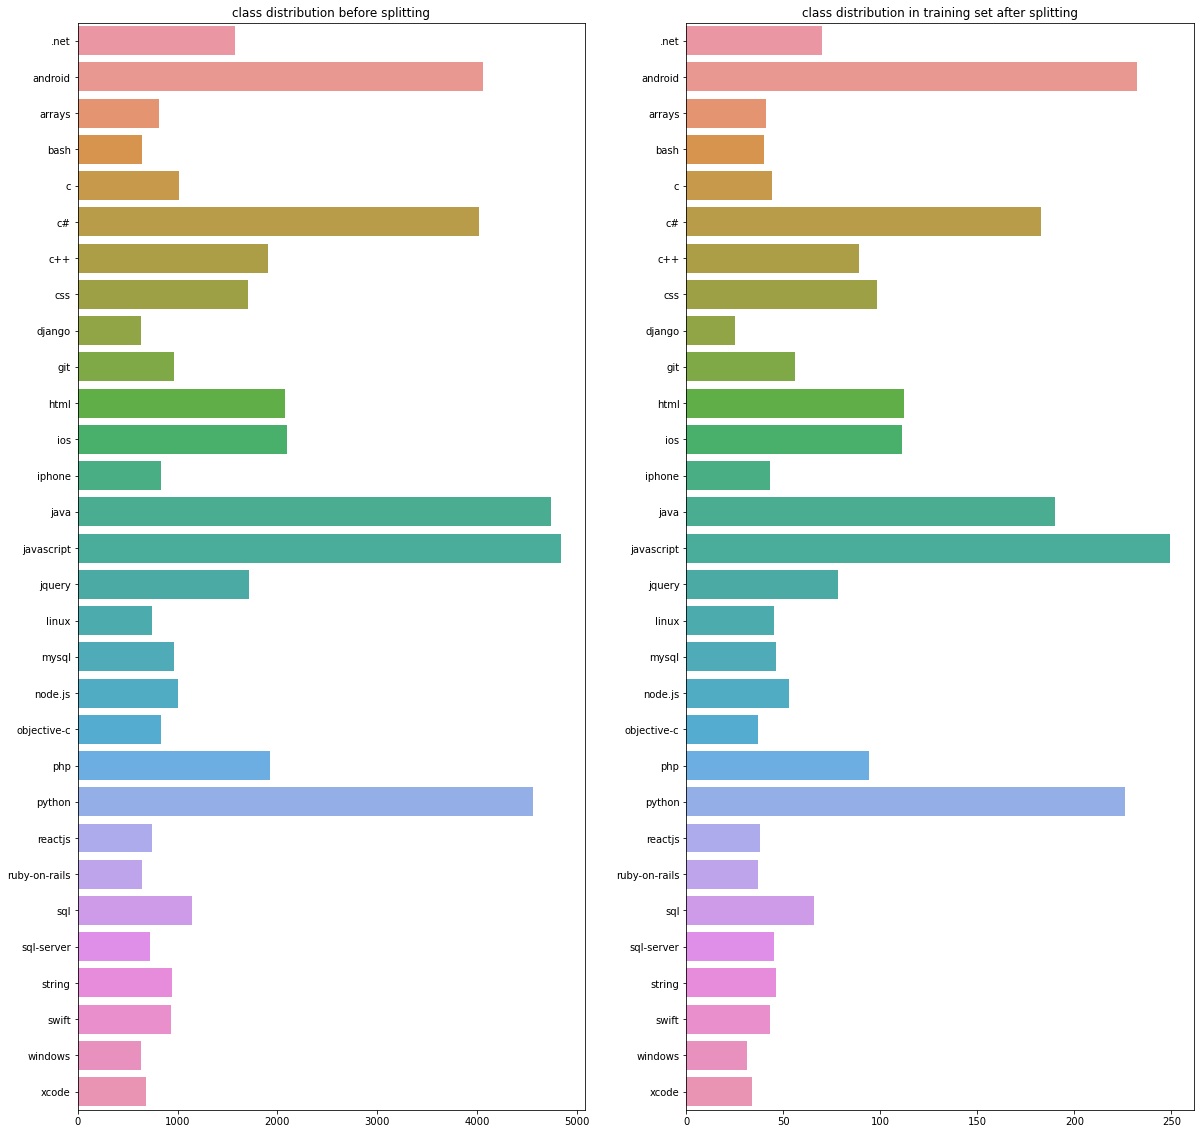

In [100]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

multilabel_binarizer = MultiLabelBinarizer()
multilabel_binarizer.fit(df_study.Tags)
Y = multilabel_binarizer.transform(df_study.Tags)
X_tfidf = tfidf

x_train_tfidf, x_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, Y, train_size=0.05, random_state=9000)



fig = plt.figure(figsize=(20,20))
(ax_test, ax_train) = fig.subplots(ncols=2, nrows=1)
g1 = sns.barplot(x=Y.sum(axis=0), y=multilabel_binarizer.classes_, ax=ax_test)
g2 = sns.barplot(x=y_train_tfidf.sum(axis=0), y=multilabel_binarizer.classes_, ax=ax_train)
g1.set_title("class distribution before splitting")
g2.set_title("class distribution in training set after splitting")



In [101]:
x_train_index, x_test_index, y_train_tfidf, y_test_tfidf = train_test_split(
    df_study.index, Y, train_size=0.05, random_state=9000)

In [102]:
multilabel_binarizer.classes_

array(['.net', 'android', 'arrays', 'bash', 'c', 'c#', 'c++', 'css',
       'django', 'git', 'html', 'ios', 'iphone', 'java', 'javascript',
       'jquery', 'linux', 'mysql', 'node.js', 'objective-c', 'php',
       'python', 'reactjs', 'ruby-on-rails', 'sql', 'sql-server',
       'string', 'swift', 'windows', 'xcode'], dtype=object)

In [103]:
df_learning = df_study.loc[x_train_index]
df_learning.to_json('tags_learning.json')
df_y_learning = pd.DataFrame(y_train_tfidf[0:-2])
df_y_learning.to_csv('tags_y_learning.csv')

[Retour en haut](#0)